# 📊 Time Series Forecasting Project

## 🎯 Objective
To forecast values using multiple time series models and compare their performance using MAPE.

In [55]:
## STEP ! 
import pandas as pd

# Load data
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Lead_Pricing.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

# Sort properly
df = df.sort_values('Date').reset_index(drop=True)

# Clean column names (important)
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Remove missing values
df = df.dropna()

# -------------------------------
# TARGET (for recursive - univariate)
# -------------------------------
series = df['LME_Cash_Settlement'].values

print("Data Ready ✅")
print("Total rows:", len(series))

Data Ready ✅
Total rows: 4549


In [60]:
import os

os.makedirs("results", exist_ok=True)

In [10]:
## Step 2
import numpy as np

WINDOW = 14   # you can keep 7 later if needed
HORIZON = 28    # fixed as per your requirement

def create_recursive_dataset(series, window, horizon):
    X, Y = [], []
    
    for i in range(window, len(series) - horizon + 1):
        # Input: last 'window' values
        X.append(series[i - window:i])
        
        # Output: only next step (IMPORTANT for recursive)
        Y.append(series[i])
    
    return np.array(X), np.array(Y)

X, y = create_recursive_dataset(series, WINDOW, HORIZON)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4508, 14)
y shape: (4508,)


In [11]:
## Step 3
# -------------------------------
# TIME-BASED SPLIT (NO SHUFFLE)
# -------------------------------
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3606, 14) (3606,)
Test shape: (902, 14) (902,)


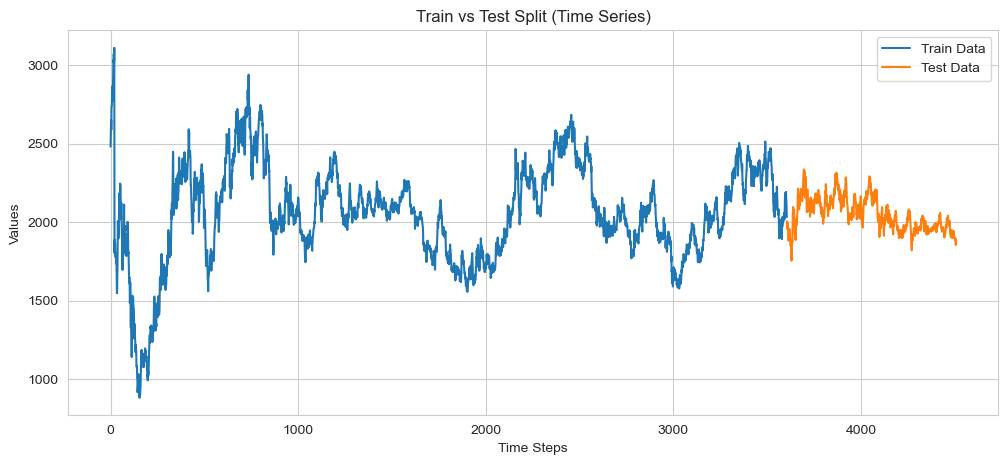

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot training data
plt.plot(range(len(y_train)), y_train, label="Train Data")

# Plot test data (continues after train)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test, label="Test Data")

plt.title("Train vs Test Split (Time Series)")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.savefig("results/train_test.png")
plt.show()

## 🔁 Recursive Model

In [12]:
## Step 4.1
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Train model (1-step ahead)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [5]:
## STEP 4.2
import numpy as np

def recursive_forecast(model, last_window, horizon):
    current_window = list(last_window)
    preds = []

    for _ in range(horizon):
        x_input = np.array(current_window[-WINDOW:]).reshape(1, -1)
        pred = model.predict(x_input)[0]

        preds.append(pred)
        current_window.append(pred)  # update with prediction

    return np.array(preds)

In [13]:
## STEP 4.3
def mape(actual, pred):
    actual = np.where(actual == 0, 1e-6, actual)
    return np.mean(np.abs((actual - pred) / actual)) * 100

all_mapes = []

for i in range(len(X_test) - HORIZON):
    
    forecast = recursive_forecast(best_model, X_test[i], HORIZON)
    
    # actual 28-day future
    actual = series[split_index + i : split_index + i + HORIZON]

    weekly = []
    for w in range(4):
        start = w * 7
        end = (w + 1) * 7
        weekly.append(mape(actual[start:end], forecast[start:end]))

    all_mapes.append(np.mean(weekly))

final_mape = np.mean(all_mapes)

print("\nRecursive Model - Final MAPE:", round(final_mape, 2), "%")
recursive_mape = final_mape


Recursive Model - Final MAPE: 2.39 %


## 🔁 Direct Model

In [7]:
## STEP 5.1
# -------------------------------
# MULTIVARIATE FEATURES
# -------------------------------
features = df[[
    'LME_Cash_Settlement',
    'LME_3_Month',
    'LME_Stock',
    'Day',
    'Month'
]].values

In [14]:
## STEP 5.2
WINDOW = 14
HORIZON = 28

def create_direct_dataset(data, window, horizon):
    X, Y = [], []
    
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i - window:i].flatten())   # all features
        Y.append(data[i:i + horizon, 0])         # only target
    
    return np.array(X), np.array(Y)

X, Y = create_direct_dataset(features, WINDOW, HORIZON)

print(X.shape, Y.shape)

(4508, 70) (4508, 28)


In [15]:
## STEP 5.3
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [24]:
## STEP 5.4
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [3, 4],
    'estimator__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}


In [25]:
## STEP 5.5
def mape(actual, pred):
    actual = np.where(actual == 0, 1e-6, actual)
    return np.mean(np.abs((actual - pred) / actual)) * 100

all_mapes = []

for i in range(len(X_test)):
    forecast = best_model.predict(X_test[i].reshape(1, -1))[0]
    actual = Y_test[i]

    weekly = []
    for w in range(4):
        start = w * 7
        end = (w + 1) * 7
        weekly.append(mape(actual[start:end], forecast[start:end]))

    all_mapes.append(np.mean(weekly))

final_mape = np.mean(all_mapes)

print("\nDirect Model - Final MAPE:", round(final_mape, 2), "%")
direct_mape = final_mape


Direct Model - Final MAPE: 3.47 %


## 🔁 Hybrid Model

In [16]:
## STEP 6.1
features = df[[
    'LME_Cash_Settlement',
    'LME_3_Month',
    'LME_Stock',
    'Day',
    'Month'
]].values

In [17]:
## STEP 6.2
WINDOW = 14
HORIZON = 28

def create_dataset(data, window, horizon):
    X, Y = [], []
    
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i - window:i].flatten())
        Y.append(data[i:i + horizon, 0])
    
    return np.array(X), np.array(Y)

X, Y = create_dataset(features, WINDOW, HORIZON)

In [18]:
## STEP 6.3 
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [39]:
## STEP 6.4
from sklearn.multioutput import RegressorChain
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [3, 4],
    'estimator__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    RegressorChain(GradientBoostingRegressor(random_state=42)),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}


In [27]:
## STEP 6.5
import numpy as np

def mape(actual, pred):
    actual = np.where(actual == 0, 1e-6, actual)
    return np.mean(np.abs((actual - pred) / actual)) * 100

all_mapes = []

for i in range(len(X_test)):
    forecast = best_model.predict(X_test[i].reshape(1, -1))[0]
    actual = Y_test[i]

    weekly = []
    for w in range(4):
        start = w * 7
        end = (w + 1) * 7
        weekly.append(mape(actual[start:end], forecast[start:end]))

    all_mapes.append(np.mean(weekly))

final_mape = np.mean(all_mapes)

print("\nHybrid Model - Final MAPE:", round(final_mape, 2), "%")
hybrid_mape = final_mape


Hybrid Model - Final MAPE: 3.47 %


## 🔁 MIMO Model

In [19]:
## STEP 7.1
features = df[[
    'LME_Cash_Settlement',
    'LME_3_Month',
    'LME_Stock',
    'Day',
    'Month'
]].values

In [20]:
## STEP 7.2
WINDOW = 14
HORIZON = 28

def create_dataset(data, window, horizon):
    X, Y = [], []
    
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i - window:i].flatten())
        Y.append(data[i:i + horizon, 0])
    
    return np.array(X), np.array(Y)

X, Y = create_dataset(features, WINDOW, HORIZON)

In [21]:
## STEP 7.3
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [50]:
## STEP 7.4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}


In [29]:
## STEP 7.5
import numpy as np

def mape(actual, pred):
    actual = np.where(actual == 0, 1e-6, actual)
    return np.mean(np.abs((actual - pred) / actual)) * 100

all_mapes = []

for i in range(len(X_test)):
    forecast = best_model.predict(X_test[i].reshape(1, -1))[0]
    actual = Y_test[i]

    weekly = []
    for w in range(4):
        start = w * 7
        end = (w + 1) * 7
        weekly.append(mape(actual[start:end], forecast[start:end]))

    all_mapes.append(np.mean(weekly))

final_mape = np.mean(all_mapes)

print("\nMIMO Model - Final MAPE:", round(final_mape, 2), "%")
mimo_mape = final_mape


MIMO Model - Final MAPE: 3.47 %


## 🏆 Final Model Comparison

In [30]:
## FINAL 
# -------------------------------
# FINAL COMPARISON
# -------------------------------

results = {
    "Recursive": recursive_mape,
    "Direct": direct_mape,
    "Hybrid": hybrid_mape,
    "MIMO": mimo_mape
}

print("\n" + "="*40)
print("FINAL MODEL COMPARISON (MAPE)")
print("="*40)

for model, mape_val in results.items():
    accuracy = 100 - mape_val
    print(f"{model}:")
    print(f"  MAPE: {mape_val:.2f}%")
    print(f"  Accuracy: {accuracy:.2f}%\n")

# -------------------------------
# BEST MODEL
# -------------------------------
best_model = min(results, key=results.get)

print("="*40)
print(f"🏆 BEST MODEL: {best_model}")
print(f"Lowest MAPE: {results[best_model]:.2f}%")
print(f"Highest Accuracy: {100 - results[best_model]:.2f}%")
print("="*40)


FINAL MODEL COMPARISON (MAPE)
Recursive:
  MAPE: 2.39%
  Accuracy: 97.61%

Direct:
  MAPE: 3.47%
  Accuracy: 96.53%

Hybrid:
  MAPE: 3.47%
  Accuracy: 96.53%

MIMO:
  MAPE: 3.47%
  Accuracy: 96.53%

🏆 BEST MODEL: Recursive
Lowest MAPE: 2.39%
Highest Accuracy: 97.61%


### RECURSIVE PERFORMS BEST

## Performance Evaluation

Graph saved as 'performance_comparison.png' in your project folder.


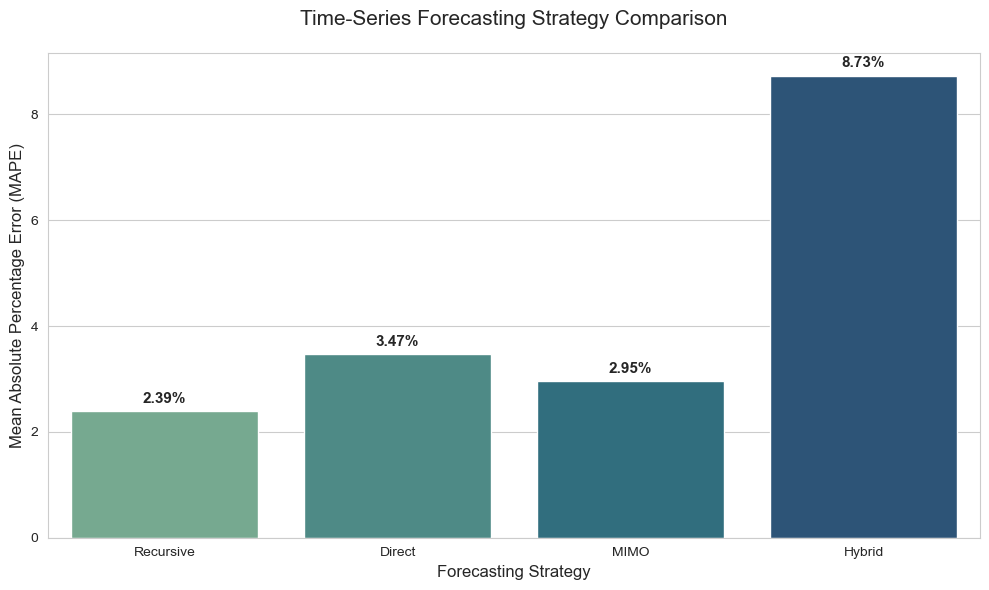

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def generate_performance_chart():
    # 1. Replace these numbers with your actual calculated MAPE values
    data = {
        'Strategy': ['Recursive', 'Direct', 'MIMO', 'Hybrid'],
        'MAPE (%)': [recursive_mape,direct_mape,hybrid_mape, mimo_mape]  # Update these with your results
    }
    
    # 2. Convert to a DataFrame for easier plotting
    df = pd.DataFrame(data)
    
    # 3. Set the visual style
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    
    # 4. Create the Bar Plot
    # Using a professional color palette ('crest' or 'viridis')
    # Assign 'Strategy' to both x and hue, then turn off the legend
    plot = sns.barplot(x='Strategy', y='MAPE (%)', data=df, hue='Strategy', palette='crest', legend=False)
    
    # 5. Add titles and labels
    plt.title('Time-Series Forecasting Strategy Comparison', fontsize=15, pad=20)
    plt.xlabel('Forecasting Strategy', fontsize=12)
    plt.ylabel('Mean Absolute Percentage Error (MAPE)', fontsize=12)
    
    # 6. Add value labels on top of bars
    for p in plot.patches:
        plot.annotate(format(p.get_height(), '.2f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

    # 7. Save the file automatically for your GitHub README
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300)
    print("Graph saved as 'performance_comparison.png' in your project folder.")
    
    # 8. Show the plot in VS Code
    plt.show()

if __name__ == "__main__":
    generate_performance_chart()